In [1]:
import numpy as np, pandas as pd
from tools.core import *

from scipy.spatial.distance import pdist, squareform
import time, ot, gc
from scipy.stats import kendalltau, pearsonr, dirichlet
import pickle


import matplotlib.pyplot as plt, seaborn as sns, matplotlib as mpl
sns.set_palette('colorblind')
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize":6, "ytick.labelsize":6, 'legend.fontsize':6, "legend.title_fontsize":7})
plt.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches

We compare the runtime for our methods vs Optimal Transport, as implemented by the `POT` module. We use the time module and disable the garbage collector to ensure accuracy.

# Experiment 1: 100 pairs

In [ ]:
def run_comparison(P, Q, C, Z, verbose=False):
    """
    Parameters:
        P : np.ndarray
            source distributions
        Q : np.array
            target distributions
        C : np.ndarray
            cost matrix
        Z : np.ndarray
            similarity matrix
        verbose : bool, default=False

    Returns:
        result : list
            [time OT exact, time JBD slow 1, time JBD fast 1, time JBD slow 2, time JBD fast 2, time JBD slow 3, time JBD fast 3]
    """
    

    result = []
    m, _ = P.shape

    # OT
    gc.disable()
    start = time.perf_counter()
    for (p,q) in zip(P,Q):
        _ = ot.emd2(p, q, C)
    end = time.perf_counter()
    result.append((end-start) / m)
    gc.enable()

    if verbose:
        print(f'OT done: {result[-1]}')


    for alpha in [1,2,3]:
        # JBD slow
        gc.disable()
        start = time.perf_counter()
        for (p,q) in zip(P,Q):
            _ = get_divergence(Z, alpha, p, q)
        end = time.perf_counter()
        result.append((end-start) / m)
        gc.enable()
        
        if verbose:
            print(f'alpha {alpha} | JBD slow done: {result[-1]}')

        # JBD fast
        gc.disable()
        start = time.perf_counter()
        _ = get_divergence(Z, alpha, P, Q)
        end = time.perf_counter()
        result.append((end-start) / m)
        gc.enable()

        if verbose:
            print(f'alpha {alpha} | JBD fast done: {result[-1]}')

    return result


def main(n_repeats, N, M, e_dim=10, verbose=False):
    """
    n_repeats : int
        Number of datasets to generate and give to compare
    N : int
        dimension of distribution
    M : int
        number of comparisons
    alpha : float
    e_dim : int, default=10
        dimension of embedding vector
    tau : float, default=1
    """

    rng = np.random.default_rng()

    results = []
    
    for _ in range(n_repeats):
        if _ % 10 == 0:
            print(_)

        P = dirichlet.rvs(alpha=[1.]*N, size=M)  # distributions are uniform
        P /= P.sum(axis=1, keepdims=True)

        Q = dirichlet.rvs(alpha=[1.]*N, size=M)  # distributions are uniform
        Q /= Q.sum(axis=1, keepdims=True)

        emb = rng.random((N, e_dim))
        C = squareform( pdist(emb) )
        Z = distance_to_similarity(C, 1)

        results.append(
            run_comparison(P, Q, C, Z, verbose=verbose)
        )

    return results


In [ ]:
### To run the experiment
n_values = [10, 100, 1000]
dict_results = {n: None for n in n_values}
for N in dict_results:
    print(N, '\n')
    dict_results[N] = pd.DataFrame(
        main(n_repeats=50, N=N, M=100, e_dim=10, verbose=False),
        columns = ['ot_exact', 'jbd_slow_1', 'jbd_fast_1', 'jbd_slow_2', 'jbd_fast_2', 'jbd_slow_3', 'jbd_fast_3']
    )

In [2]:
### Results reported in the paper
with open("outputs/OT_comparison/dict_results_100pairs.pkl", "rb") as f:
    dict_results = pickle.load(f)

Text(0.5, 0.01, 'size of distribution $(n)$')

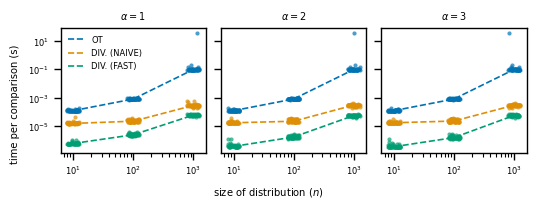

In [3]:
fig, axes = plt.subplots(1,3,figsize=(2.5*16/3.*cm, 5*cm), layout='constrained', sharex=True, sharey=True)
for alpha, ax in zip([1,2,3], axes):
    for i, txt in enumerate(['ot_exact', f'jbd_slow_{alpha}', f'jbd_fast_{alpha}']):
        temp = {N: dict_results[N][txt] for N in dict_results}
        sns.stripplot(
            temp, color=sns.color_palette()[i], log_scale=(True, True), native_scale=True, alpha=0.7, ax=ax, s=3, marker='o'
        )
        ax.plot(
            temp.keys(), [np.median(x) for x in temp.values()], color=sns.color_palette()[i], ls='--', label=['OT', 'DIV. (NAIVE)', 'DIV. (FAST)'][i]
        )
    
    ax.set_yticks([1e-5, 1e-3, 1e-1, 10])
    if alpha == 1:
        ax.legend(frameon=False,)
    ax.set_title(r'$\alpha = $' + str(alpha))
fig.supylabel('time per comparison (s)')
fig.supxlabel('size of distribution ' + r'$(n)$')

# Experiment 2: All-pairs

## The algorithms

In [ ]:
def pairwise_emd(P: np.ndarray, C: np.ndarray) -> np.ndarray:
    """
    Condensed pairwise exact OT (emd2) distances for rows of P with cost matrix C.
    Returns 1D condensed array like scipy.spatial.distance.pdist.
    """
    P = np.asarray(P, dtype=float)
    M, N = P.shape
    assert C.shape == (N, N)

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty(0, dtype=float)

    
    idx = 0
    for i in range(M - 1):
        a = P[i]
        for j in range(i + 1, M):
            b = P[j]
            out[idx] = ot.emd2(a, b, C)   # exact EMD^1 cost
            idx += 1
    return out


def pairwise_jbd_slow(P: np.ndarray, Z: np.ndarray, alpha: float) -> np.ndarray:
    """
    Condensed pairwise JB distances for rows of P with Z
    Returns 1D condensed array like scipy.spatial.distance.pdist.
    """
    P = np.asarray(P, dtype=float)
    M, N = P.shape
    assert Z.shape == (N, N)

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty(0, dtype=float)

    out = np.empty(L, dtype=float)
    idx = 0
    for i in range(M - 1):
        a = P[i]
        for j in range(i + 1, M):
            b = P[j]
            out[idx] = get_entropy(Z, alpha, (a+b)/2) - 0.5*(get_entropy(Z, alpha, a) + get_entropy(Z, alpha, b))
            idx += 1
    return out

def pairwise_jbd_fast(P: np.ndarray,
                      Z: np.ndarray,
                      alpha: float,
                      eps: float = 1e-16,
                      block=None) -> np.ndarray:
    """
    Vectorised all-pairs Jensen-Bregman divergence.

    Supports alpha = 1, alpha = 2, and general alpha != 1, 2.
    Assumes Z is square and compatible with P.
    """
    P = np.asarray(P, dtype=float)
    Z = np.asarray(Z, dtype=float)

    M, N = P.shape
    assert Z.shape == (N, N)

    # Normalize distributions row-wise
    P = np.maximum(P, eps)
    row_sums = P.sum(axis=1, keepdims=True)
    if np.any(row_sums == 0):
        raise ValueError("Some rows of P sum to zero after clamping.")
    P = P / row_sums

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty((0,), dtype=float)

    # Heuristic block size
    if block is None:
        approx = int(10_000_000 // max(1, M * N))
        block = max(1, min(M, approx))
    block = int(block)

    ZP = P @ Z
    ZP = np.maximum(ZP, eps)

    is_alpha_1 = np.isclose(alpha, 1.0)
    is_alpha_2 = np.isclose(alpha, 2.0)

    if is_alpha_1:
        # S_p[i] = sum_k P[i,k] * log((P[i] @ Z)[k])
        S_p = np.einsum('ij,ij->i', P, np.log(ZP))
    elif is_alpha_2:
        # S_p[i] = sum_k P[i,k] * (P[i] @ Z)[k]
        pZp = np.einsum('ij,ij->i', P, ZP)
    else:
        a1 = alpha - 1.0
        ZP_a1 = ZP ** a1
        S_p = np.einsum('ij,ij->i', P, ZP_a1)

    cond = np.empty(L, dtype=float)

    for i in range(M - 1):
        Pi = P[i]
        ZPi = ZP[i]

        if is_alpha_2:
            pZp_i = pZp[i]
        else:
            S_p_i = S_p[i]

        j_start = i + 1
        for j0 in range(j_start, M, block):
            j1 = min(M, j0 + block)
            Q = P[j0:j1, :]              # (B, N)
            ZQ = ZP[j0:j1, :]            # (B, N)
            ZQ = np.maximum(ZQ, eps)

            if is_alpha_2:
                # cross = p_i^T Z p_j, using symmetry of Z
                cross = ZPi @ Q.T  # (B,)

                pZp_js = pZp[j0:j1]
                J_block = 0.25 * (pZp_i + pZp_js - 2.0 * cross)

            elif is_alpha_1:
                # Direct alpha = 1 limit:
                # J(p,q) = 0.5*(F(p)+F(q)) - F((p+q)/2),
                # with F(r) = sum_k r_k log((r @ Z)_k)
                logZQ = np.log(ZQ)

                r = 0.5 * (Pi[None, :] + Q)                 # (B, N)
                Zr = 0.5 * (ZPi[None, :] + ZQ)
                Zr = np.maximum(Zr, eps)

                S_q_block = np.einsum('ij,ij->i', Q, logZQ)
                S_r = np.einsum('ij,ij->i', r, np.log(Zr))

                J_block = 0.5 * (S_p_i + S_q_block) - S_r

            else:
                a1 = alpha - 1.0

                ZQ_a1 = ZQ ** a1
                Zr = 0.5 * (ZPi[None, :] + ZQ)
                Zr = np.maximum(Zr, eps)
                Zr_a1 = Zr ** a1

                r = 0.5 * (Pi[None, :] + Q)

                S_q_block = np.einsum('ij,ij->i', Q, ZQ_a1)
                S_r = np.einsum('ij,ij->i', r, Zr_a1)

                J_block = (0.5 * (S_p_i + S_q_block) - S_r) / a1

            start_idx = i * M - (i * (i + 1)) // 2 + (j0 - i - 1)
            cond[start_idx:start_idx + (j1 - j0)] = J_block

    return cond

In [ ]:
def run_comparison(P, C, Z, n_runs, verbose=False):
    """
    Parameters:
        P : np.ndarray
            distributions
        C : np.ndarray
            cost matrix
        Z : np.ndarray
            similarity matrix
        n_runs : int
            number of runs to average time over
        verbose : bool, default=False

    Returns:
        result : list
            [time OT exact, time JBD slow 1, time JBD fast 1, time JBD slow 2, time JBD fast 2, time JBD slow 3, time JBD fast 3]
    """
    

    result = []

    # OT
    gc.disable()
    start = time.perf_counter()
    for _ in range(n_runs):
        ot = pairwise_emd(P, C)
    end = time.perf_counter()
    result.append((end-start)/n_runs)
    gc.enable()

    if verbose:
        print(f'OT done: {result[-1]}')


    for alpha in [1,2,3]:
        # JBD slow
        gc.disable()
        start = time.perf_counter()
        for _ in range(n_runs):
            jbd = pairwise_jbd_slow(P, Z, alpha)
        end = time.perf_counter()
        result.append((end-start)/n_runs)
        gc.enable()
        
        if verbose:
            print(f'alpha {alpha} | JBD slow done: {result[-1]}')

        # JBD fast
        gc.disable()
        start = time.perf_counter()
        for _ in range(n_runs):
            jbd = pairwise_jbd_fast(P, Z, alpha)
        end = time.perf_counter()
        result.append((end-start)/n_runs)
        gc.enable()

        if verbose:
            print(f'alpha {alpha} | JBD fast done: {result[-1]}')


    return result

In [ ]:
def main(n_repeats, n_runs, N, M, e_dim=10, tau=1., verbose=False):
    """
    n_repeats : int
        Number of datasets to generate and give to run_comparison
    n_runs : int
        Passed on to compare
    N : int
        number of distributions
    M : int
        length of distributions
    alpha : float
    e_dim : int, default=10
        dimension of embedding vector
    tau : float, default=1
    """

    rng = np.random.default_rng()

    results = []
    counter, failed_counter = 0, 0
    while counter < n_repeats and failed_counter < 10*n_repeats:
        print(counter)

        P = dirichlet.rvs(alpha=[1.]*M, size=N)  # distributions are uniform
        P /= P.sum(axis=1, keepdims=True)

        emb = rng.random((M, e_dim))
        C = squareform( pdist(emb) )
        Z = distance_to_similarity(C, tau)

        # check if it works for alpha=3
        if np.array([is_CND(get_hessian(Z, 3, p)) for p in P]).all():
            results.append(
                run_comparison(P, C, Z, n_runs, verbose=verbose)
            )
            counter += 1
        else:
            print(f"Failed: {failed_counter}")
            failed_counter += 1

    return results


In [ ]:
### Run experiment
input_sizes = np.array(np.logspace(2, 6, 5, base=np.sqrt(10)), dtype=int)

dict_results = {N: None for N in input_sizes}
for N in dict_results:
    print(N, '\n')
    dict_results[N] = pd.DataFrame(
        main(n_repeats=10, n_runs=1, N=N, M=50, e_dim=10, tau=1.),
        columns = ['ot_exact', 'jbd_slow_1', 'jbd_fast_1', 'jbd_slow_2', 'jbd_fast_2', 'jbd_slow_3', 'jbd_fast_3']
    )

In [2]:
### Results reported in the paper
with open("outputs/OT_comparison/dict_results_allpairs.pkl", "rb") as f:
    dict_results = pickle.load(f)

Text(0.5, 0.01, 'number of comparisons $\\left( O \\left(m^2\\right) \\right)$')

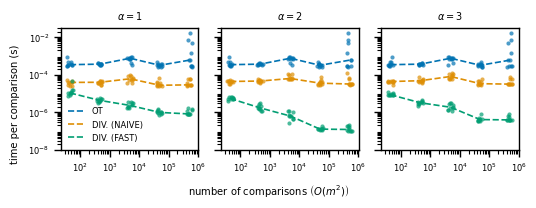

In [3]:
fig, axes = plt.subplots(1,3,figsize=(2.5*16/3.*cm, 5*cm), layout='constrained', sharex=True, sharey=True)
for alpha, ax in zip([1,2,3], axes):
    for i, txt in enumerate(['ot', f'jbd_slow_{alpha}', f'jbd_fast_{alpha}']):
        temp = {N*(N-1)/2: dict_results[N][txt]/(N*(N-1)/2) for N in dict_results}
        sns.stripplot(
            temp, color=sns.color_palette()[i], log_scale=(True, True), native_scale=True, alpha=0.7, ax=ax, s=3, marker='o'
        )
        ax.plot(
            temp.keys(), [np.median(x) for x in temp.values()], color=sns.color_palette()[i], ls='--', label=['OT', 'DIV. (NAIVE)', 'DIV. (FAST)'][i]
        )
    if alpha == 1:
        ax.legend(frameon=False)
    ax.set_title(r'$\alpha = $' + str(alpha))
    ax.set_ylim(10**-8, 10**-1.5)
    ax.set_yticks([1e-8, 1e-6, 1e-4, 1e-2])
fig.supylabel('time per comparison (s)')
fig.supxlabel('number of comparisons ' + r'$\left( O \left(m^2\right) \right)$')

## Results for $\alpha=2$ (Replicates Fig. 2)

In [5]:
### Results reported in the paper
with open("outputs/OT_comparison/dict_results_100pairs.pkl", "rb") as f:
    dict_results_1 = pickle.load(f)

with open("outputs/OT_comparison/dict_results_allpairs.pkl", "rb") as f:
    dict_results_2 = pickle.load(f)

In [11]:
dict_results_2.keys()

dict_keys([10, 31, 100, 316, 1000])

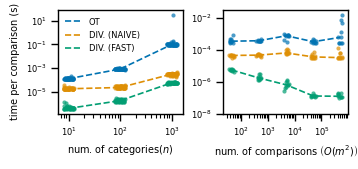

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(8.8*cm, 4*cm), layout='constrained', )

ax= axes[0]
for i, txt in enumerate(['ot_exact', f'jbd_slow_{2}', f'jbd_fast_{2}']):
    temp = {N: dict_results_1[N][txt] for N in dict_results_1}
    sns.stripplot(
        temp, color=sns.color_palette()[i], log_scale=(True, True), native_scale=True, alpha=0.7, ax=ax, s=3, marker='o'
    )
    ax.plot(
        temp.keys(), [np.median(x) for x in temp.values()], color=sns.color_palette()[i], ls='--', label=['OT', 'DIV. (NAIVE)', 'DIV. (FAST)'][i]
    )
ax.set_yticks([1e-5, 1e-3, 1e-1, 10])
ax.legend(frameon=False)

ax = axes[1]
for i, txt in enumerate(['ot', f'jbd_slow_{2}', f'jbd_fast_{2}']):
    temp = {N*(N-1)/2: dict_results_2[N][txt]/(N*(N-1)/2) for N in dict_results_2}
    sns.stripplot(
        temp, color=sns.color_palette()[i], log_scale=(True, True), native_scale=True, alpha=0.7, ax=ax, s=3, marker='o'
    )
    ax.plot(
        temp.keys(), [np.median(x) for x in temp.values()], color=sns.color_palette()[i], ls='--', label=['OT', 'DIV. (NAIVE)', 'DIV. (FAST)'][i]
    )
ax.set_ylim(10**-8, 10**-1.5)
ax.set_yticks([1e-8, 1e-6, 1e-4, 1e-2])

axes[0].set_ylabel('time per comparison (s)')
axes[0].set_xlabel('num. of categories' + r'$\left( n \right)$')
axes[1].set_xlabel('num. of comparisons ' + r'$\left( O \left(m^2\right) \right)$')